# User+WC MoE: Decay vs No Decay

Tests whether time-decay weighting helps the User+WC MoE approach.
Compares flat weighting (rate=0) vs decay (rate=0.03) on the winning configuration.

**Dataset:** NLR Kestrel, expanded window (~193 days, 2.7M rows)
**Model:** XGBoost Adjusted (200 trees, depth 12)
**Lookback:** 120 days
**Rolling eval:** 120 windows × 6h

## 1. Setup

In [1]:
from datetime import datetime, timedelta, timezone
from pathlib import Path
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.compute as pc
import pyarrow.parquet as pq

from hpc_oda_commons.models.experimental.xgboost_adjusted_model import (
    ExperimentalXGBoostAdjustedConfig, ExperimentalXGBoostAdjustedModel,
)

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})

REPO_ROOT = Path.cwd().parent.parent
DATA_PATH = REPO_ROOT / 'workspace' / 'data' / 'datasets' / 'nlr_kestrel' / 'data.parquet'

In [2]:
# Load with enough history for 120-day lookback
table = pq.read_table(DATA_PATH)
lo = datetime(2025, 1, 1, tzinfo=timezone.utc)
hi = datetime(2025, 6, 26, tzinfo=timezone.utc) + timedelta(days=1)
sc = table.column('submit_time')
ec = table.column('end_time')
mask = pc.and_(
    pc.less(sc, pa.scalar(hi, type=sc.type)),
    pc.greater_equal(ec, pa.scalar(lo, type=ec.type)),
)
df = table.filter(mask).to_pandas()
rows_all = df.to_dict('records')
print(f'Loaded: {len(rows_all):,} rows')
print(f'Date range: {df["submit_time"].min().date()} to {df["submit_time"].max().date()}')
span = (df['submit_time'].max() - df['submit_time'].min()).days
print(f'Span: {span} days')

Loaded: 2,702,850 rows
Date range: 2024-12-15 to 2025-06-26
Span: 193 days


## 2. Configuration

In [3]:
N_WINDOWS = 120
TEST_WINDOW_HOURS = 6
TRAINING_LOOKBACK_DAYS = 120
DECAY_RATE = 0.03

POWER_USER_PERCENTILE = 0.99

BIN_EDGES_H = [0, 2, 4, 24, 48, float('inf')]
BIN_LABELS = ['<=2h', '2-4h', '4-24h', '24-48h', '>48h']

def make_config(decay_rate):
    return ExperimentalXGBoostAdjustedConfig(
        n_windows=N_WINDOWS,
        test_window_hours=TEST_WINDOW_HOURS,
        training_lookback_days=TRAINING_LOOKBACK_DAYS,
        max_svd_components=64,
        target_max_one_hot_width=512,
        random_state=42,
        n_estimators=200,
        max_depth=12,
        learning_rate=0.03,
        min_child_weight=5,
        gamma=0.1,
        time_decay_rate=decay_rate,
        estimator_n_jobs=6,
    )

print(f'Windows: {N_WINDOWS} x {TEST_WINDOW_HOURS}h = {N_WINDOWS*TEST_WINDOW_HOURS/24:.0f} days test')
print(f'Lookback: {TRAINING_LOOKBACK_DAYS} days')
print(f'Decay rate: {DECAY_RATE} (day 0=1.0, day 60={np.exp(-DECAY_RATE*60):.2f}, day 120={np.exp(-DECAY_RATE*120):.2f})')

Windows: 120 x 6h = 30 days test
Lookback: 120 days
Decay rate: 0.03 (day 0=1.0, day 60=0.17, day 120=0.03)


## 3. Helpers

In [4]:
import time

def assign_bin(row):
    wc_h = (row.get('requested_seconds') or 0) / 3600
    for i in range(len(BIN_EDGES_H) - 1):
        if wc_h <= BIN_EDGES_H[i + 1]:
            return BIN_LABELS[i]
    return BIN_LABELS[-1]


def run_user_wc_moe(rows_all, power_users, decay_rate):
    """Run full User+WC MoE with given decay rate.
    Returns (combined_result, per_bin_results) where per_bin_results is a dict
    stored in memory (survives browser disconnects)."""
    all_payloads = []
    per_bin = {}  # stored results — survives even if print output is lost
    
    # Pre-compute all bins
    bin_jobs = []
    for user in sorted(power_users):
        user_rows = [r for r in rows_all if r.get('user') == user]
        user_bins = {}
        for r in user_rows:
            bl = assign_bin(r)
            user_bins.setdefault(bl, []).append(r)
        for bl in BIN_LABELS:
            bin_rows = user_bins.get(bl, [])
            if len(bin_rows) >= 100:
                bin_jobs.append((f'power {user[:7]}/{bl}', bin_rows))
    
    non_power_rows = [r for r in rows_all if r.get('user') not in power_users]
    np_bins = {}
    for r in non_power_rows:
        bl = assign_bin(r)
        np_bins.setdefault(bl, []).append(r)
    for bl in BIN_LABELS:
        bin_rows = np_bins.get(bl, [])
        if len(bin_rows) >= 100:
            bin_jobs.append((f'non-power/{bl}', bin_rows))
    
    total_bins = len(bin_jobs)
    start_time = time.time()
    
    for idx, (bin_name, bin_rows) in enumerate(bin_jobs):
        elapsed = (time.time() - start_time) / 60
        if idx > 0:
            avg_per_bin = elapsed / idx
            remaining = avg_per_bin * (total_bins - idx)
        else:
            remaining = 0
        
        print(f'  [{idx+1}/{total_bins} bins | {elapsed:.0f}min elapsed | ~{remaining:.0f}min remaining] '
              f'{bin_name} ({len(bin_rows):,} rows)...')
        
        bin_start = time.time()
        try:
            model = ExperimentalXGBoostAdjustedModel(make_config(decay_rate))
            payload = model.evaluate(bin_rows, capture_artifacts=True)
            if payload['summary']['rows_scored'] > 0:
                all_payloads.append(payload)
                bin_elapsed = (time.time() - bin_start) / 60
                per_bin[bin_name] = {
                    'scored': payload['summary']['rows_scored'],
                    'mae': payload['mae'],
                    'rmse': payload['rmse'],
                    'rows': len(bin_rows),
                }
                print(f'    -> scored={payload["summary"]["rows_scored"]:,}, MAE={payload["mae"]:,.0f}s ({bin_elapsed:.1f}min)', flush=True)
        except Exception as e:
            print(f'    -> FAILED: {e}', flush=True)
    
    total_elapsed = (time.time() - start_time) / 60
    print(f'  [DONE | {total_elapsed:.0f}min total]', flush=True)
    
    # Combine
    all_true = []
    all_pred = []
    for p in all_payloads:
        if '_y_true' in p and '_y_pred' in p:
            all_true.extend(p['_y_true'])
            all_pred.extend(p['_y_pred'])
    
    if not all_true:
        return None, per_bin
    all_true = np.array(all_true)
    all_pred = np.array(all_pred)
    mae = np.mean(np.abs(all_true - all_pred))
    rmse = np.sqrt(np.mean((all_true - all_pred)**2))
    combined = {'mae': mae, 'rmse': rmse, 'scored': len(all_true)}
    return combined, per_bin


# Identify power users
user_counts = Counter(r.get('user') for r in rows_all)
threshold = np.percentile(list(user_counts.values()), POWER_USER_PERCENTILE * 100)
power_users = {u for u, c in user_counts.items() if c >= threshold}
power_jobs = sum(1 for r in rows_all if r.get('user') in power_users)
print(f'Power users: {len(power_users)} ({power_jobs:,} jobs, {power_jobs/len(rows_all)*100:.1f}%)', flush=True)


Power users: 8 (1,477,501 jobs, 54.7%)


## 4. Run: Flat weighting (rate=0)

In [5]:
print('Running User+WC MoE with FLAT weighting (rate=0)...', flush=True)
result_flat, per_bin_flat = run_user_wc_moe(rows_all, power_users, 0.0)
if result_flat:
    print(f'\n  FLAT: MAE={result_flat["mae"]:,.0f}s, RMSE={result_flat["rmse"]:,.0f}s, scored={result_flat["scored"]:,}', flush=True)


Running User+WC MoE with FLAT weighting (rate=0)...
  [1/32 bins | 0min elapsed | ~0min remaining] power 05630e6/4-24h (49,826 rows)...


100%|████████████████████████████████████████████████████████████████████████████████| 120/120 [00:00<00:00, 229.05it/s]


    -> scored=33,320, MAE=2,346s (0.6min)
  [2/32 bins | 1min elapsed | ~20min remaining] power 24b498e/<=2h (1,808 rows)...


100%|███████████████████████████████████████████████████████████████████████████████| 120/120 [00:00<00:00, 5661.41it/s]


    -> scored=24, MAE=561s (0.0min)
  [3/32 bins | 1min elapsed | ~10min remaining] power 24b498e/2-4h (10,762 rows)...


...

    -> scored=42,677, MAE=5,766s (17.4min)
  [31/32 bins | 69min elapsed | ~5min remaining] non-power/24-48h (263,179 rows)...


100%|█████████████████████████████████████████████████████████████████████████████████| 120/120 [00:03<00:00, 34.51it/s]


    -> scored=41,545, MAE=22,146s (76.7min)
  [32/32 bins | 145min elapsed | ~5min remaining] non-power/>48h (17,483 rows)...


100%|████████████████████████████████████████████████████████████████████████████████| 120/120 [00:00<00:00, 656.03it/s]


    -> scored=2,013, MAE=69,324s (3.7min)
  [DONE | 149min total]

  FLAT: MAE=3,272s, RMSE=13,885s, scored=615,896


## 5. Run: Time-decay weighting (rate=0.03)

In [ ]:
print(f'Running User+WC MoE with DECAY weighting (rate={DECAY_RATE})...', flush=True)
result_decay, per_bin_decay = run_user_wc_moe(rows_all, power_users, DECAY_RATE)
if result_decay:
    print(f'\n  DECAY: MAE={result_decay["mae"]:,.0f}s, RMSE={result_decay["rmse"]:,.0f}s, scored={result_decay["scored"]:,}', flush=True)


Running User+WC MoE with DECAY weighting (rate=0.03)...
  [1/32 bins | 0min elapsed | ~0min remaining] power 05630e6/4-24h (49,826 rows)...


100%|████████████████████████████████████████████████████████████████████████████████| 120/120 [00:00<00:00, 203.00it/s]


    -> scored=33,320, MAE=1,010s (0.9min)
  [2/32 bins | 1min elapsed | ~29min remaining] power 24b498e/<=2h (1,808 rows)...


100%|███████████████████████████████████████████████████████████████████████████████| 120/120 [00:00<00:00, 5602.99it/s]


    -> scored=24, MAE=487s (0.0min)
  [3/32 bins | 1min elapsed | ~14min remaining] power 24b498e/2-4h (10,762 rows)...


...

100%|█████████████████████████████████████████████████████████████████████████████████| 120/120 [00:04<00:00, 25.80it/s]


    -> scored=42,677, MAE=5,880s (16.7min)
  [31/32 bins | 68min elapsed | ~5min remaining] non-power/24-48h (263,179 rows)...


100%|█████████████████████████████████████████████████████████████████████████████████| 120/120 [00:03<00:00, 36.29it/s]


    -> scored=41,545, MAE=21,472s (12.0min)
  [32/32 bins | 80min elapsed | ~3min remaining] non-power/>48h (17,483 rows)...


100%|████████████████████████████████████████████████████████████████████████████████| 120/120 [00:00<00:00, 627.96it/s]


## 6. Results

In [10]:
print('=' * 60)
print('RESULTS: FLAT vs DECAY')
print('=' * 60)

if result_flat and result_decay:
    print(f'\n{"Approach":<30} {"MAE":>10} {"RMSE":>10} {"Scored":>10}')
    print('-' * 65)
    print(f'{"Flat (rate=0)":<30} {result_flat["mae"]:>10,.0f}s {result_flat["rmse"]:>10,.0f}s {result_flat["scored"]:>10,}')
    print(f'{f"Decay (rate={DECAY_RATE})":<30} {result_decay["mae"]:>10,.0f}s {result_decay["rmse"]:>10,.0f}s {result_decay["scored"]:>10,}')
    
    diff = (result_decay['mae'] - result_flat['mae']) / result_flat['mae'] * 100
    print(f'\nDifference: {diff:+.1f}% MAE')
    if diff < -2:
        print('Time-decay HELPS — recent jobs are more informative than older ones.')
    elif diff > 2:
        print('Time-decay HURTS — older jobs are still relevant, weighting them down loses signal.')
    else:
        print('Minimal difference — decay has negligible effect at this lookback length.')

RESULTS: FLAT vs DECAY

Approach                              MAE       RMSE     Scored
-----------------------------------------------------------------
Flat (rate=0)                       3,272s     13,885s    615,896
Decay (rate=0.03)                   3,138s     13,972s    615,896

Difference: -4.1% MAE
Time-decay HELPS — recent jobs are more informative than older ones.


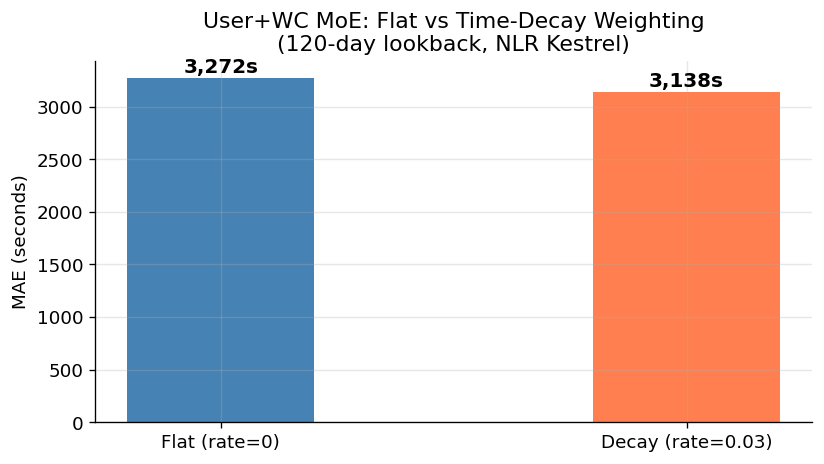

In [11]:
# Simple bar chart
if result_flat and result_decay:
    fig, ax = plt.subplots(figsize=(7, 4))
    names = ['Flat (rate=0)', f'Decay (rate={DECAY_RATE})']
    maes = [result_flat['mae'], result_decay['mae']]
    bars = ax.bar(names, maes, color=['steelblue', 'coral'], width=0.4)
    for bar, mae in zip(bars, maes):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                f'{mae:,.0f}s', ha='center', fontsize=12, fontweight='bold')
    ax.set_ylabel('MAE (seconds)')
    ax.set_title('User+WC MoE: Flat vs Time-Decay Weighting\n(120-day lookback, NLR Kestrel)')
    plt.tight_layout()
    plt.show()

## 7. Per-Bin Comparison Table

Side-by-side comparison of flat vs decay MAE for each bin.
Run this cell AFTER the notebook completes and is saved.

In [12]:
# Per-bin comparison table — reads from stored dicts (survives browser disconnect)
print(f'Flat bins: {len(per_bin_flat)}, Decay bins: {len(per_bin_decay)}')
print()
print(f'{"Bin":<35} {"Scored":>8} {"Flat MAE":>10} {"Decay MAE":>10} {"Change":>10}')
print('-' * 78)

for bin_name in sorted(per_bin_flat.keys(), key=lambda b: -per_bin_flat[b]['scored']):
    f = per_bin_flat[bin_name]
    d = per_bin_decay.get(bin_name)
    if d:
        change = (d['mae'] - f['mae']) / f['mae'] * 100 if f['mae'] > 0 else 0
        marker = ' <<<' if change < -10 else (' >>>' if change > 10 else '')
        print(f'{bin_name:<35} {f["scored"]:>8,} {f["mae"]:>10,.0f}s {d["mae"]:>10,.0f}s {change:>+9.1f}%{marker}')
    else:
        print(f'{bin_name:<35} {f["scored"]:>8,} {f["mae"]:>10,.0f}s {"(missing)":>10}')


Flat bins: 32, Decay bins: 32

Bin                                   Scored   Flat MAE  Decay MAE     Change
------------------------------------------------------------------------------
power c6b628f/<=2h                   210,721        174s        161s      -7.3%
power f781187/2-4h                   100,587        480s        475s      -1.0%
non-power/<=2h                        73,054        443s        422s      -4.7%
non-power/4-24h                       42,677      5,766s      5,880s      +2.0%
non-power/24-48h                      41,545     22,146s     21,472s      -3.0%
non-power/2-4h                        38,387      1,720s      1,703s      -1.0%
power 05630e6/4-24h                   33,320      2,346s      1,010s     -56.9% <<<
power c6b628f/4-24h                   28,523      3,530s      3,498s      -0.9%
power b5fe0d4/24-48h                  10,596     21,226s     20,905s      -1.5%
power cdb4f00/<=2h                     9,172        727s        732s      +0.7%
power 24